In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("Diwali Sales Data.csv",  encoding="unicode_escape")

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.9 MB


In [28]:
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [29]:
df["Amount"] = df["Amount"].fillna(0)

In [30]:
df["Amount"].mean()

np.float64(9443.527902408676)

In [31]:
df["Amount"].astype(int)

0        23952
1        23934
2        23924
3        23912
4        23877
         ...  
11246      370
11247      367
11248      213
11249      206
11250      188
Name: Amount, Length: 11251, dtype: int64

In [32]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11251.000000,0.0,0.0
mean,1.003004e+06,35.421207,0.420318,2.489290,9443.527902,NaN,NaN
std,1.716125e+03,12.754122,0.493632,1.115047,5228.684037,NaN,NaN
min,1.000001e+06,12.000000,0.000000,1.000000,0.000000,NaN,NaN
25%,1.001492e+06,27.000000,0.000000,1.500000,5440.000000,NaN,NaN
50%,1.003065e+06,33.000000,0.000000,2.000000,8108.000000,NaN,NaN
75%,1.004430e+06,43.000000,1.000000,3.000000,12671.000000,NaN,NaN
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,NaN,NaN


In [34]:
#specific columns description.
df[["Age", "Orders", "Amount"]].describe()

,Age,Orders,Amount
count,11251.000000,11251.000000,11251.000000
mean,35.421207,2.489290,9443.527902
std,12.754122,1.115047,5228.684037
min,12.000000,1.000000,0.000000
25%,27.000000,1.500000,5440.000000
50%,33.000000,2.000000,8108.000000
75%,43.000000,3.000000,12671.000000
max,92.000000,4.000000,23952.000000


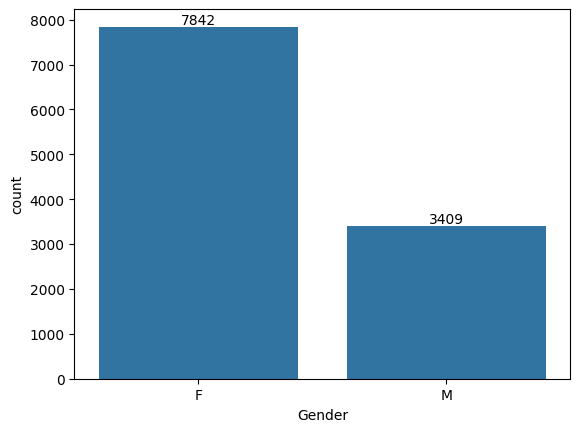

In [41]:
#exploratory Data 
ax = sns.countplot(x="Gender", data=df)
for container in ax.containers:
    ax.bar_label(container)

In [53]:
sales_gender = df.groupby(["Gender"], as_index=False)["Amount"].sum().sort_values(by="Amount", ascending=False)

In [54]:
sales_gender

,Gender,Amount
0,F,74335856.43
1,M,31913276.00


<Axes: >

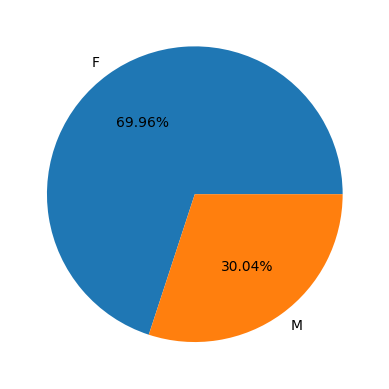

In [67]:
colors = ["#439773", "#466B7F"]
sale_by_gender = df.groupby("Gender")['Amount'].sum()
sale_by_gender.plot(kind="pie", autopct="%.2f%%")

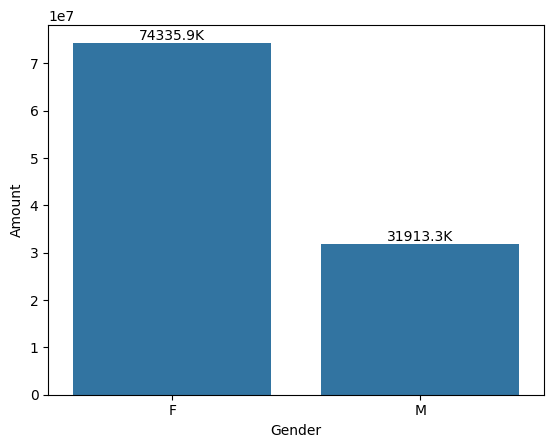

In [75]:
plt.Figure(figsize=(12,6))
ax = sns.barplot(x="Gender", y="Amount", data=sales_gender)

for container in ax.containers:
    labels = [f"{value/1_000:.1f}K" for value in container.datavalues]
    ax.bar_label(container, labels=labels)

plt.show()

In [79]:
product_sales = df.groupby(['Product_Category'], as_index=False)["Amount"].sum().sort_values(by="Amount",ascending=False)

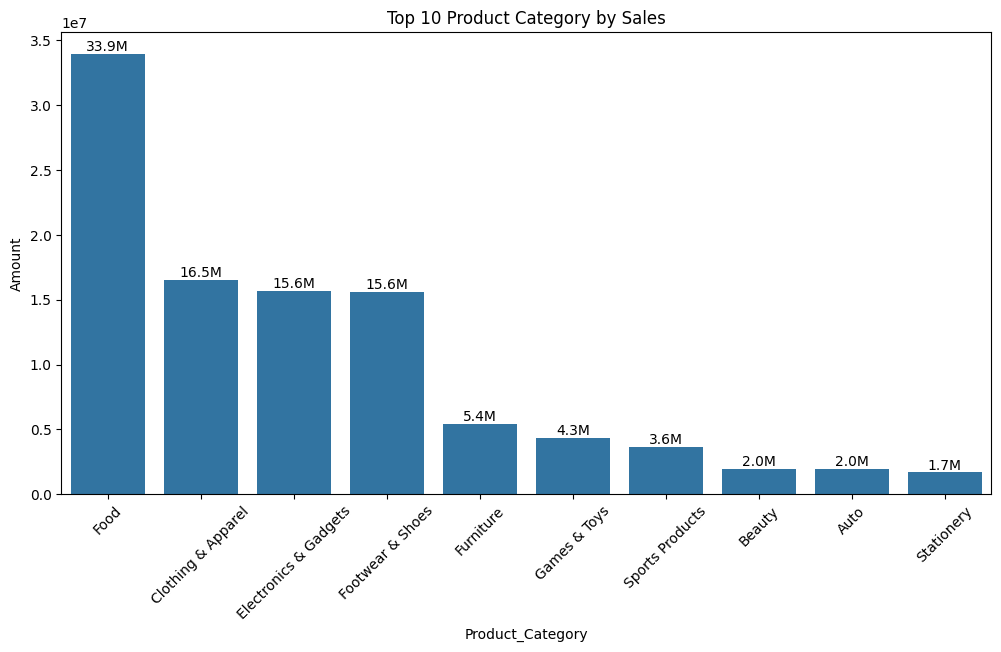

In [90]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Product_Category", y="Amount", data=product_sales.head(10))

for container in ax.containers:
    labels = [f"{value/1_000_000:.1f}M" for value in container.datavalues]
    ax.bar_label(container, labels=labels)

plt.title("Top 10 Product Category by Sales")
plt.xticks(rotation=45)
plt.show()

In [98]:
sales_by_occupation = pd.pivot_table(
    df,
    index="Occupation",
    values="Amount",
    aggfunc="sum", 
    sort=True
    
)


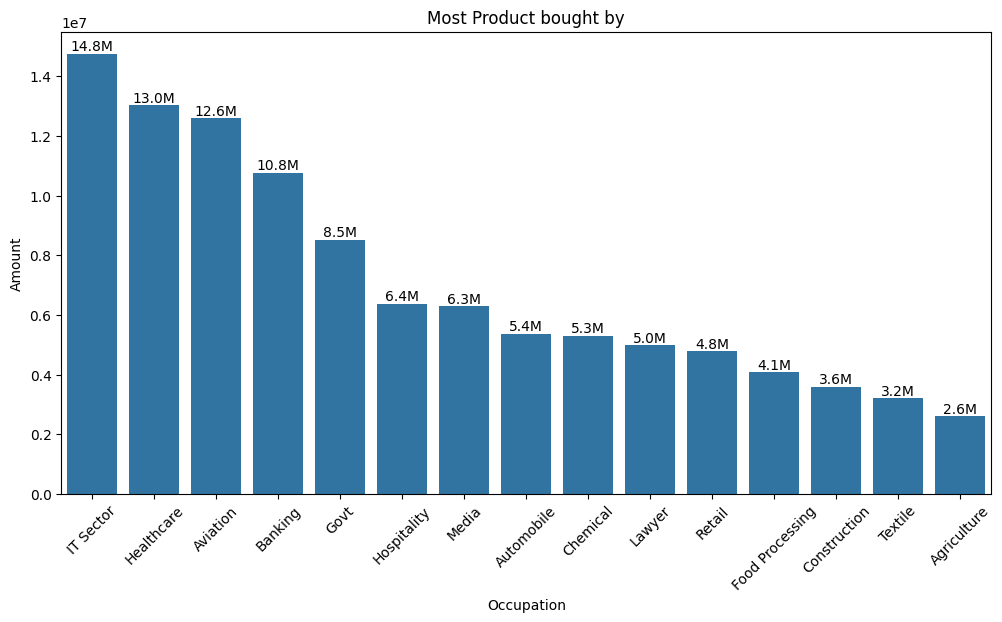

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x="Occupation", 
    y="Amount", 
    data=sales_by_occupation
    .sort_values
    (
        by="Amount",
        ascending=False)
    )

for container in ax.containers:
    labels = [f"{value/1_000_000:.1f}M" for value in container.datavalues]
    ax.bar_label(container, labels=labels)

ax.set_title("Most Products bought by")

plt.xticks(rotation=45)

plt.show()

In [120]:
num_sale_zone = (df.groupby('State')["Orders"]
                 .count()
                 .sort_values(ascending=False)
                 
                 ).reset_index()


In [121]:
num_sale_zone.columns = ["State", "Num_sales"]

In [117]:
num_sale_zone

State
Uttar Pradesh       1946
Maharashtra         1526
Karnataka           1305
Delhi               1107
Madhya Pradesh       923
Andhra Pradesh       812
Himachal Pradesh     608
Kerala               453
Haryana              452
Bihar                434
Gujarat              429
Jharkhand            380
Uttarakhand          320
Rajasthan            231
Punjab               200
Telangana            125
Name: Orders, dtype: int64

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'Uttar Pradesh'),
  Text(1, 0, 'Maharashtra'),
  Text(2, 0, 'Karnataka'),
  Text(3, 0, 'Delhi'),
  Text(4, 0, 'Madhya Pradesh'),
  Text(5, 0, 'Andhra\xa0Pradesh'),
  Text(6, 0, 'Himachal Pradesh'),
  Text(7, 0, 'Kerala'),
  Text(8, 0, 'Haryana'),
  Text(9, 0, 'Bihar'),
  Text(10, 0, 'Gujarat'),
  Text(11, 0, 'Jharkhand'),
  Text(12, 0, 'Uttarakhand'),
  Text(13, 0, 'Rajasthan'),
  Text(14, 0, 'Punjab'),
  Text(15, 0, 'Telangana')])

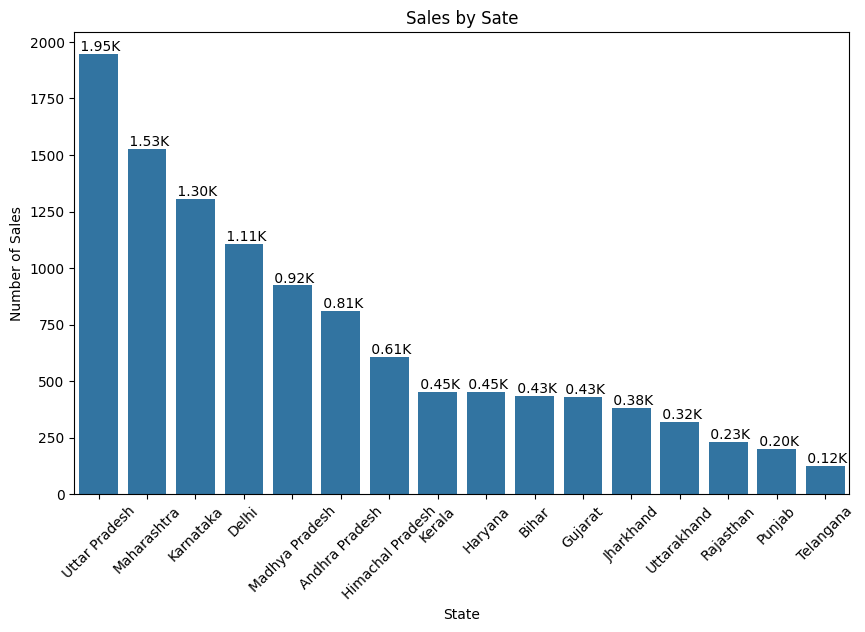

In [132]:
plt.figure(figsize=(10,6))
ax = sns.barplot(x="State", y="Num_sales", data=num_sale_zone)

for container in ax.containers:
    labels = [f"{value/1_000: .2f}K" for value in container.datavalues]
    ax.bar_label(container, labels=labels)

plt.title("Sales by Sate")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45)


In [139]:
Age_group = pd.pivot_table(
    df,
    index="Age Group",
    values="Amount",
    aggfunc="sum", 
    sort=False
)

Age_group

,Amount
Age Group,
26-35,42613443.94
0-17,2699653.00
18-25,17240732.00
55+,4080987.00
46-50,9207844.00
51-55,8261477.00
36-45,22144995.49


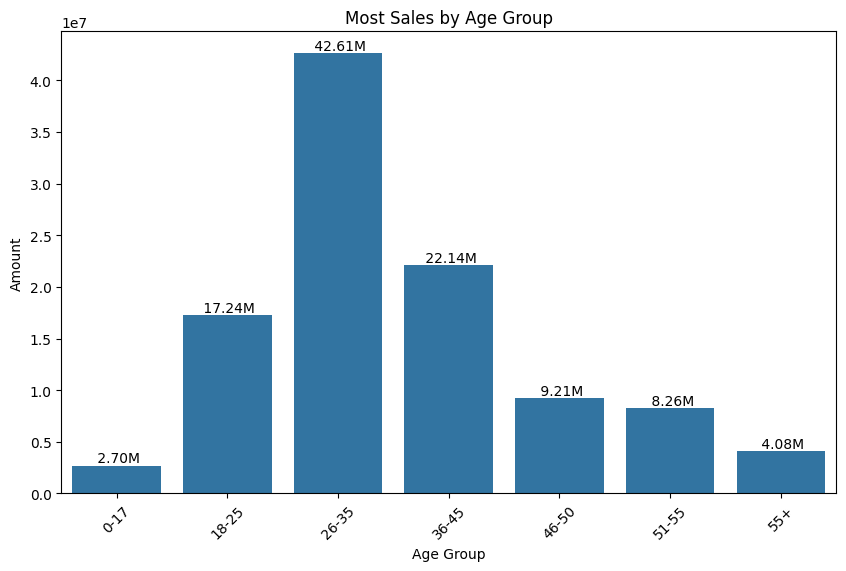

In [149]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Age Group", y="Amount", data=Age_group.sort_values(by="Age Group", ascending=True))

for container in ax.containers:
    labels = [f"{value/1_000_000: .2f}M" for value in container.datavalues]
    ax.bar_label(container, labels=labels)

plt.title("Most Sales by Age Group")
plt.xticks(rotation=45)
plt.show()

Text(0.5, 1.0, 'Identifing Customer the dominant age groups ')

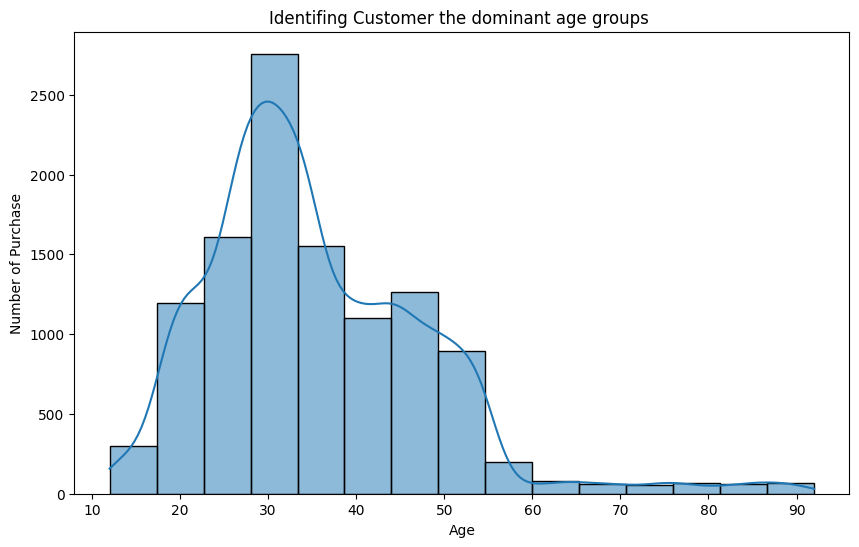

In [154]:
plt.figure(figsize=(10,6))
ax = sns.histplot(df["Age"], bins=15, kde=True)

plt.ylabel("Number of Purchase")

plt.title("Identifing Customer the dominant age groups ")


Text(0, 0.5, 'Number of Prucases')

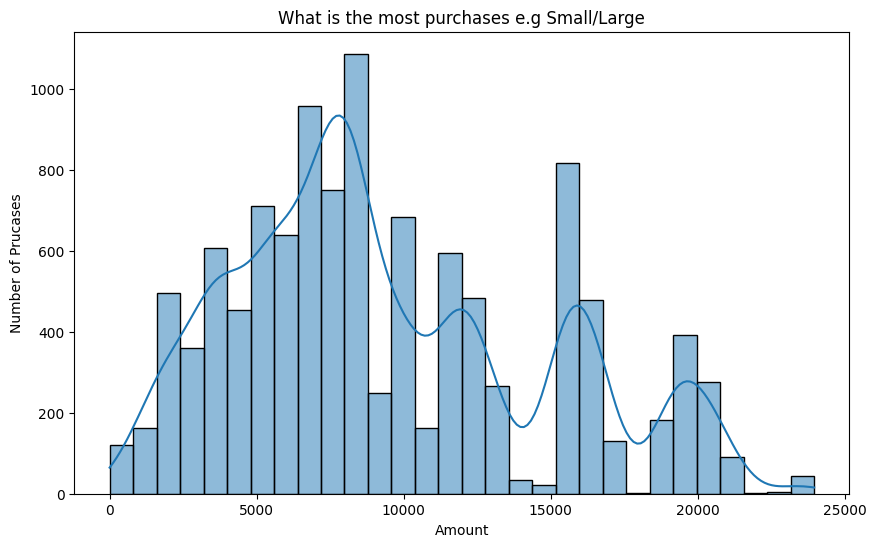

In [158]:
plt.figure(figsize=(10,6))
ax = sns.histplot(df["Amount"], bins=30, kde=True)

plt.title("What is the most purchases e.g Small/Large")
plt.ylabel("Number of Prucases")

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'Auto'),
  Text(1, 0, 'Hand & Power Tools'),
  Text(2, 0, 'Stationery'),
  Text(3, 0, 'Tupperware'),
  Text(4, 0, 'Footwear & Shoes'),
  Text(5, 0, 'Furniture'),
  Text(6, 0, 'Food'),
  Text(7, 0, 'Games & Toys'),
  Text(8, 0, 'Sports Products'),
  Text(9, 0, 'Books'),
  Text(10, 0, 'Electronics & Gadgets'),
  Text(11, 0, 'Decor'),
  Text(12, 0, 'Clothing & Apparel'),
  Text(13, 0, 'Beauty'),
  Text(14, 0, 'Household items'),
  Text(15, 0, 'Pet Care'),
  Text(16, 0, 'Veterinary'),
  Text(17, 0, 'Office')])

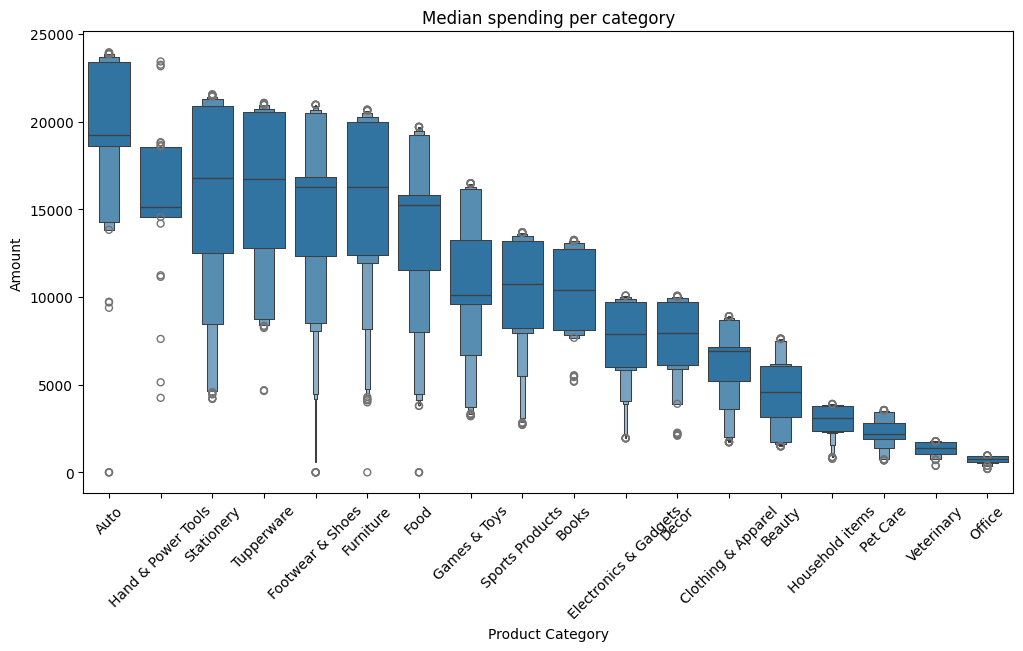

In [164]:
plt.figure(figsize=(12,6))
ax = sns.boxenplot(x = "Product_Category", y = "Amount", data=df)
plt.title("Median spending per category")
plt.xlabel("Product Category")
plt.xticks(rotation=45)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '0-17'),
  Text(1, 0, '18-25'),
  Text(2, 0, '26-35'),
  Text(3, 0, '36-45'),
  Text(4, 0, '46-50'),
  Text(5, 0, '51-55'),
  Text(6, 0, '55+')])

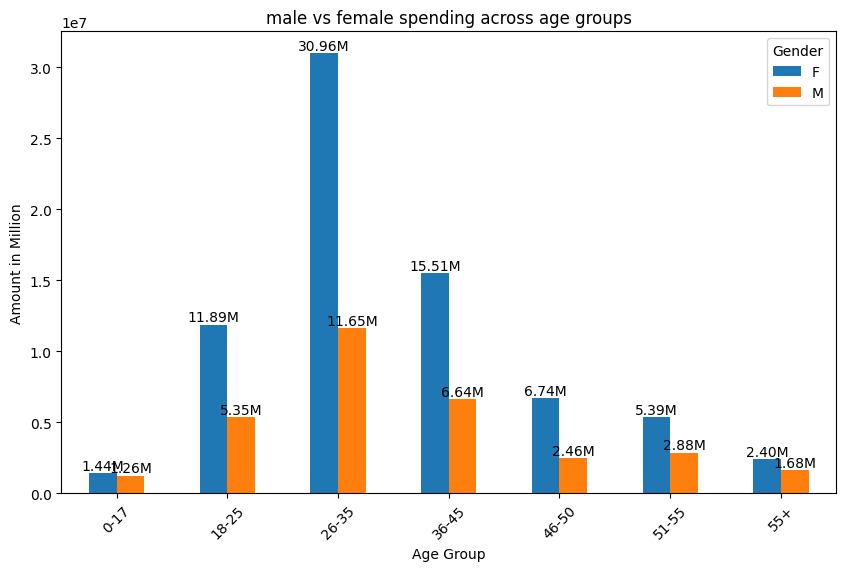

In [175]:
amount_gender_Age = pd.pivot_table(
    df,
    index="Age Group",
    columns="Gender",
    values="Amount",
    aggfunc="sum"
)

ax = amount_gender_Age.plot(kind="bar", figsize=(10,6))

for container in ax.containers:
    labels = [f"{value/1_000_000:.2f}M" for value in container.datavalues]
    ax.bar_label(container, labels=labels)
plt.title("male vs female spending across age groups")
plt.ylabel("Amount in Million")
plt.xticks(rotation=45)

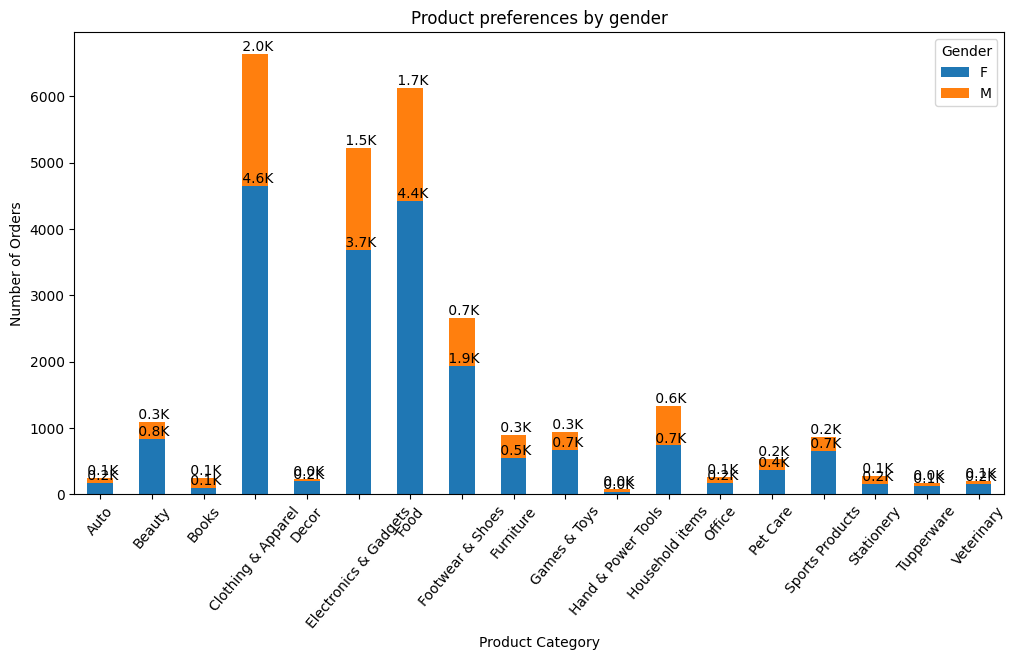

In [188]:
#product preferences

product_preference = pd.pivot_table(
    df, 
    index="Product_Category",
    columns="Gender",
    values="Orders",
    aggfunc="sum"
)

ax = product_preference.plot(kind="bar", stacked=True, figsize=(12, 6))

for container in ax.containers:
    labels = [f"{value/1_000: .1f}K" for value in container.datavalues]
    ax.bar_label(container, labels=labels)

plt.title("Product preferences by gender")
plt.ylabel("Number of Orders")
plt.xlabel("Product Category")
plt.xticks(rotation=50)

plt.show()

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Central'),
  Text(1, 0, 'Eastern'),
  Text(2, 0, 'Northern'),
  Text(3, 0, 'Southern'),
  Text(4, 0, 'Western')])

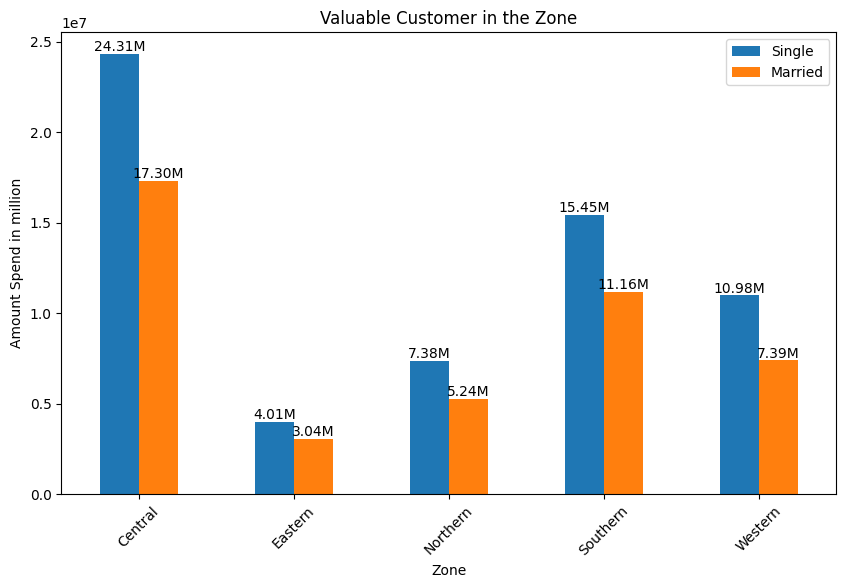

In [214]:
zonal_preference = pd.pivot_table(
    df,
    index="Zone",
    columns="Marital_Status",
    values="Amount",
    aggfunc="sum", 
    
)
zonal_preference.columns = ["Single", "Married"]
zonal_preference.sort_values(by="Single", ascending=False)

ax = zonal_preference.plot(kind="bar", figsize=(10,6))

for container in ax.containers:
    labels = [f"{value/1_000_000:.2f}M" for value in container.datavalues]
    ax.bar_label(container, labels=labels)

plt.title("Valuable Customer in the Zone")
plt.ylabel("Amount Spend in million")

plt.xticks(rotation=45)

Text(0.5, 1.0, ' occupations prefer vs product categories')

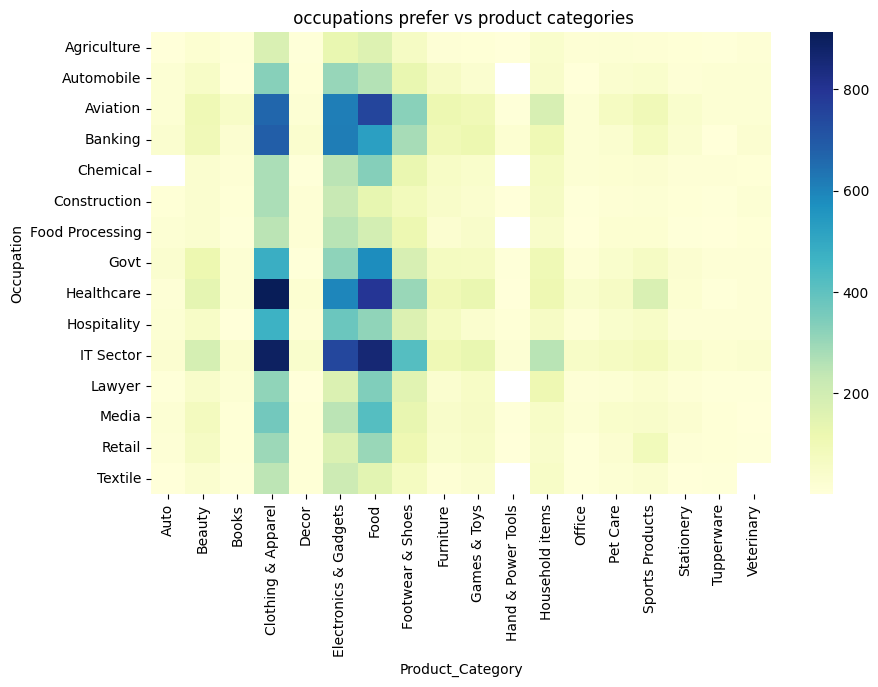

In [219]:
order_by_occupation = pd.pivot_table(
    df,
    index="Occupation", 
    columns="Product_Category",
    values="Orders",
    aggfunc="sum"
)

plt.figure(figsize=(10,6))

sns.heatmap(order_by_occupation, cmap="YlGnBu")
plt.title(" occupations prefer vs product categories")

Text(0.5, 0, 'Marital Status')

<Figure size 1000x600 with 0 Axes>

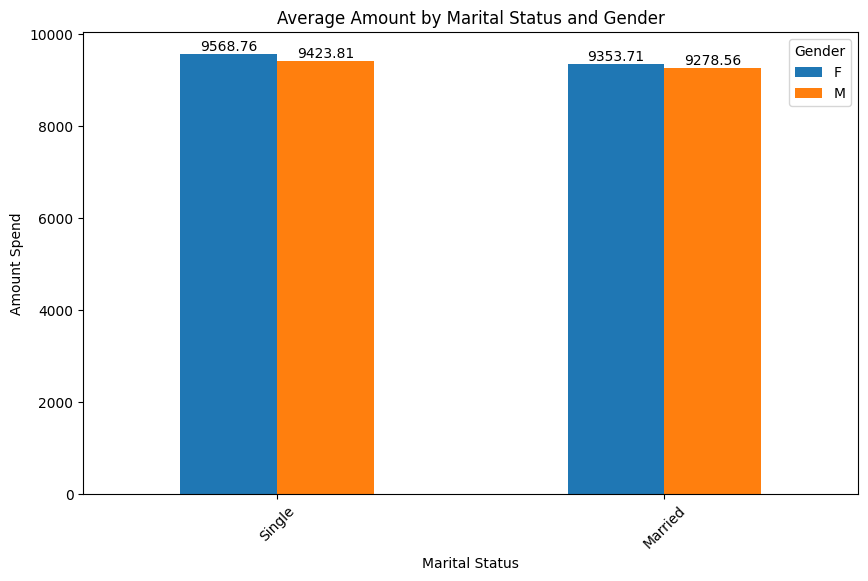

In [235]:
marrital_status = pd.pivot_table(
    df,
    index="Marital_Status",
    columns="Gender",
    values="Amount",
    aggfunc="mean"
)

marrital_status = marrital_status.rename(
    index={0: "Single", 1: "Married"}
)

plt.figure(figsize=(10,6))
ax = marrital_status.plot(kind="bar", figsize=(10,6))



for container in ax.containers:
    
    ax.bar_label(container)

plt.title("Average Amount by Marital Status and Gender")
plt.xticks(rotation=45)
plt.ylabel("Amount Spend")
plt.xlabel("Marital Status")

Text(0.5, 1.0, 'Zone-wise Revenue Contribution')

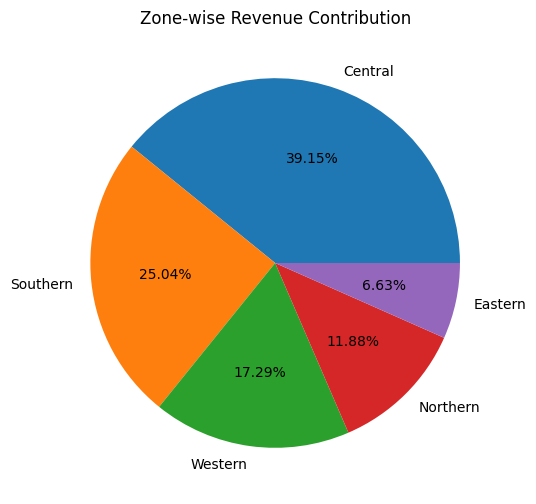

In [239]:
zone_wis_revenu = df.groupby("Zone")["Amount"].sum().sort_values(ascending=False)

zone_wis_revenu.plot(kind="pie", figsize=(6,6), autopct="%1.2f%%")

plt.title("Zone-wise Revenue Contribution")

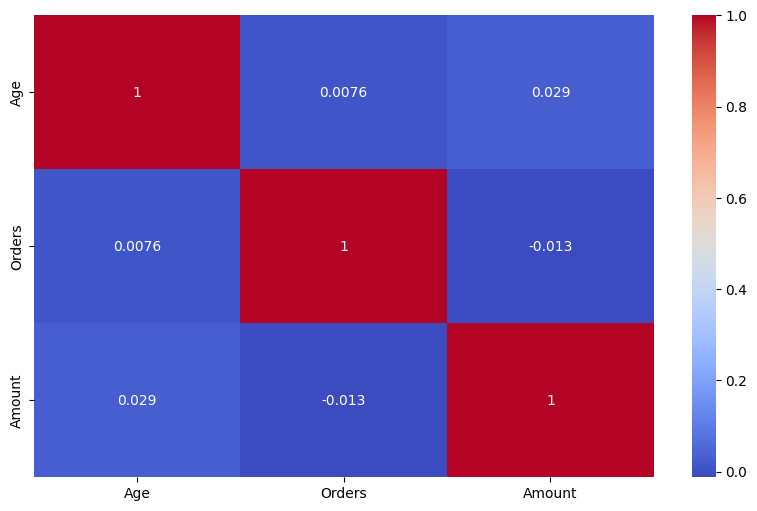

In [244]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df[["Age", "Orders", "Amount"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

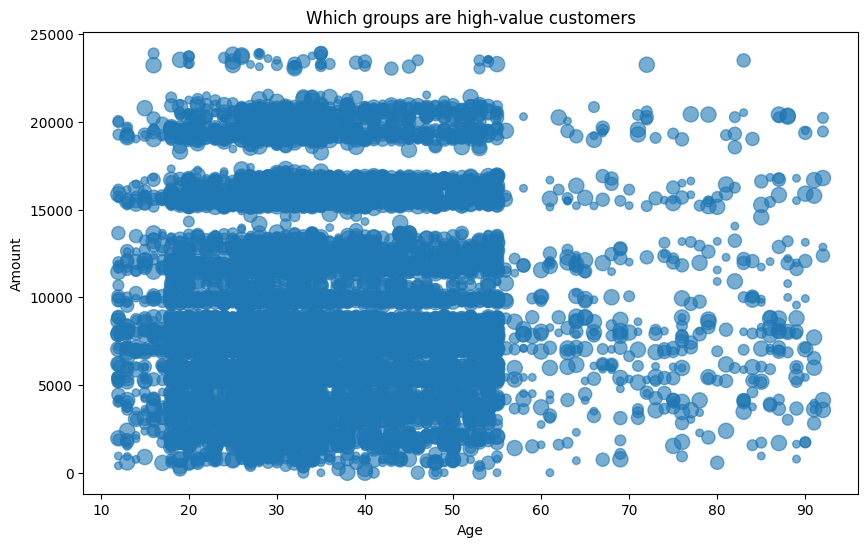

In [ ]:
#Which groups are high-value customers
plt.figure(figsize=(10,6))

plt.scatter(
    df["Age"],
    df["Amount"],
    s=df["Orders"]*30,
    alpha=0.6
)
plt.title("Which groups are high-value customers")
plt.xlabel("Age")
plt.ylabel("Amount")
plt.show()

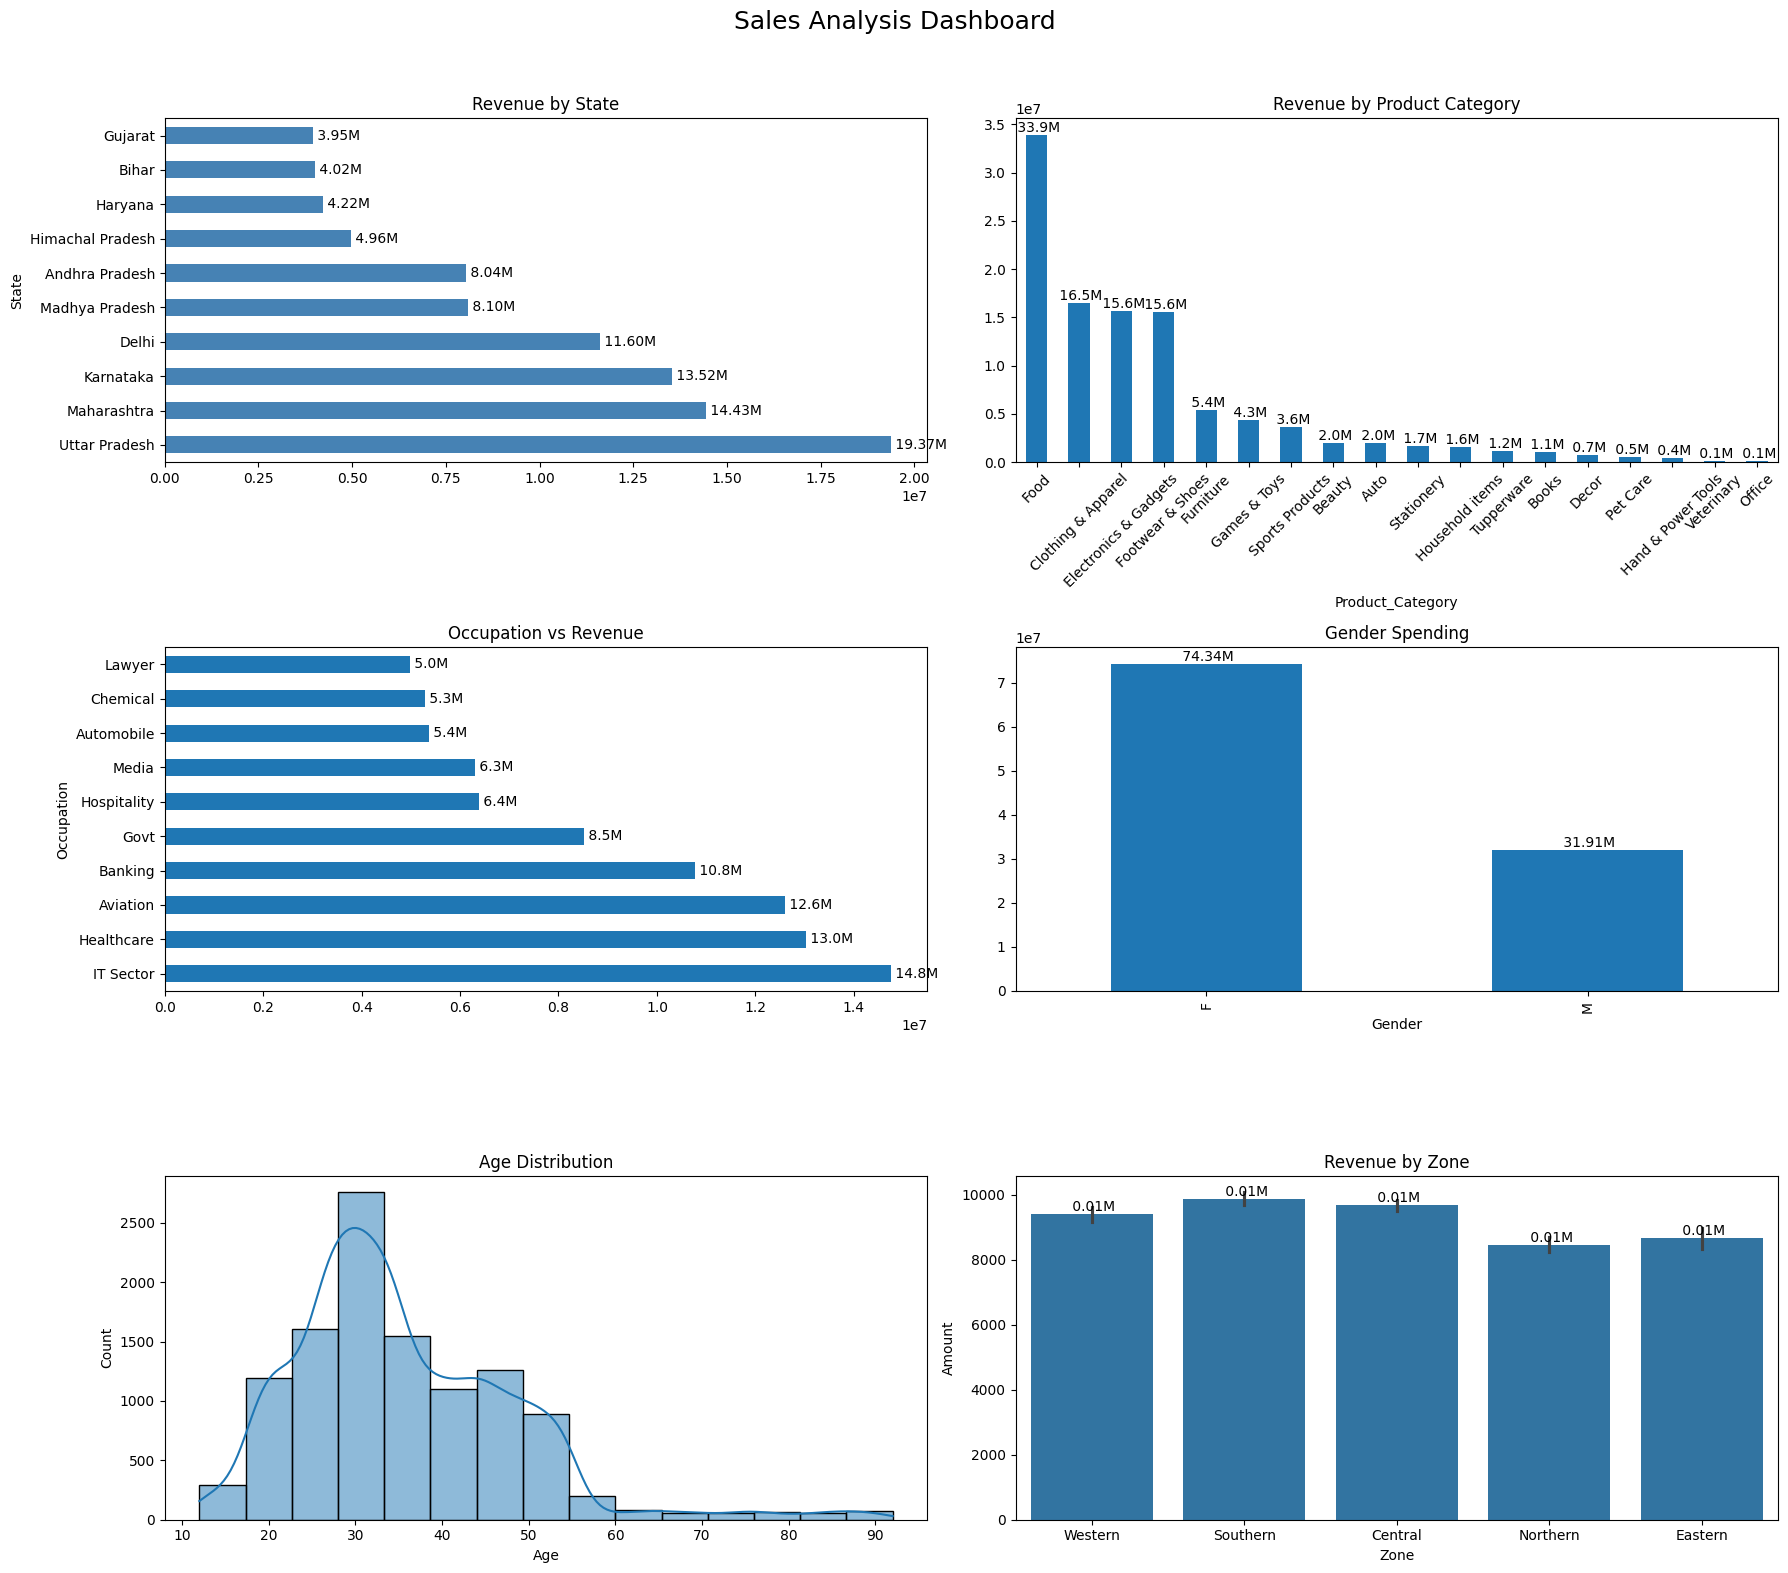

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle("Sales Analysis Dashboard", fontsize=18)

# 1. Revenue by State (Top 10)
state_sales = df.groupby("State")["Amount"].sum().nlargest(10)
ax = state_sales.plot(kind="barh", ax=axes[0,0], color="steelblue")
for container in ax.containers:
    labels = [f"{value/1_000_000: .2f}M" for value in container.datavalues]
    ax.bar_label(container, labels=labels)
axes[0,0].set_title("Revenue by State")

# 2. Product Category
category_sales = df.groupby("Product_Category")["Amount"].sum().sort_values(ascending=False)
ax = category_sales.plot(kind="bar", ax=axes[0,1])
for container in ax.containers:
    labels = [f"{value/1_000_000: .1f}M" for value in container.datavalues]
    ax.bar_label(container, labels=labels)
axes[0,1].set_title("Revenue by Product Category")
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Occupation
occ_sales = df.groupby("Occupation")["Amount"].sum().nlargest(10)
ax = occ_sales.plot(kind="barh", ax=axes[1,0])
for container in ax.containers:
    labels = [f"{value/1_000_000: .1f}M" for value in container.datavalues]
    ax.bar_label(container, labels=labels)
axes[1,0].set_title("Occupation vs Revenue")

# 4. Gender
gender_sales = df.groupby("Gender")["Amount"].sum()
ax = gender_sales.plot(kind="bar", ax=axes[1,1])
for container in ax.containers:
    labels = [f"{value/1_000_000: .2f}M" for value in container.datavalues]
    ax.bar_label(container, labels=labels)
axes[1,1].set_title("Gender Spending")

# 5. Age Distribution
sns.histplot(df["Age"], bins=15, kde=True, ax=axes[2,0], color="steelblue")
axes[2,0].set_title("Age Distribution")


# 6. Orders vs Amount
ax = sns.barplot(x="Zone", y="Amount", data=df)
for container in ax.containers:
    labels = [f"{value/1_000_000: .2f}M" for value in container.datavalues]
    ax.bar_label(container, labels=labels)
plt.title("Revenue by Zone")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()